
===== DISTANCIAS ENTRE VALLES =====

Datos 1:
[17.1 20.6 15.3]
Promedio = 17.666666666666668 V

Datos 2:
[29.9 19.1]
Promedio = 24.5 V


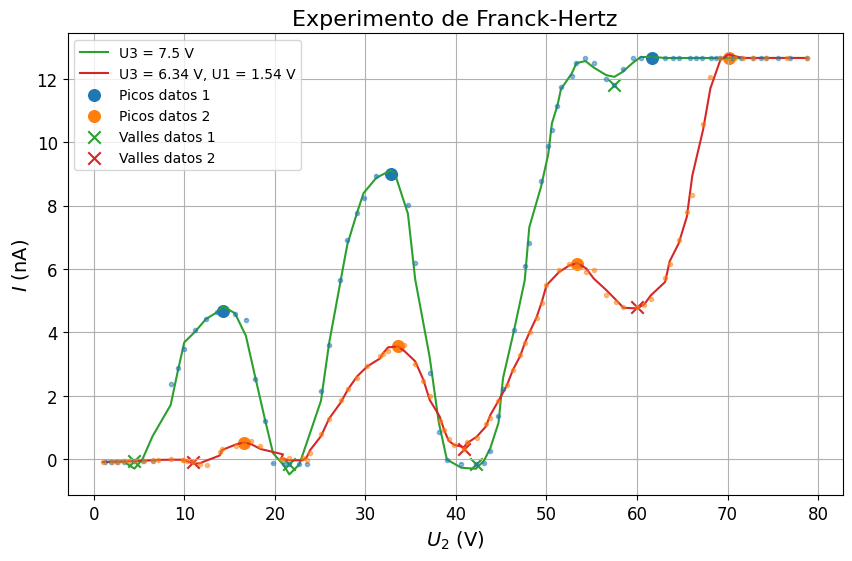

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from pandas import read_csv
from scipy.signal import savgol_filter, find_peaks


# =========================================================
# FUNCIÓN PARA ENCONTRAR PICOS
# =========================================================

def encontrar_picos(y,
                    suavizado=7,
                    orden=3,
                    prominencia=0.02,
                    distancia=15):

    # Convertir a arreglo numpy
    y = np.array(y)

    # Suavizar señal
    y_suave = savgol_filter(y, suavizado, orden)

    # Detectar picos
    picos, propiedades = find_peaks(
        y_suave,
        prominence=prominencia,
        distance=distancia
    )

    return picos, y_suave


# =========================================================
# CARGAR DATOS
# =========================================================

data_1 = read_csv('Data_01.csv')
data_2 = read_csv('Data_02.csv')

# Corrección de signo
data_1.loc[data_1['ua'] < 0.2, 'ua'] *= -1
data_2.loc[data_2['ua'] < 0.2, 'ua'] *= -1

# Variables
ua1 = data_1['ua']
ua2 = data_2['ua']

u2_1 = data_1['u2']
u2_2 = data_2['u2']

# =========================================================
# ENCONTRAR PICOS
# =========================================================

picos_1, suave_1 = encontrar_picos(ua1)
picos_2, suave_2 = encontrar_picos(ua2)

# =========================================================
# ENCONTRAR VALLES
# (invertimos la señal)
# =========================================================

valles_1, _ = encontrar_picos(-ua1)
valles_2, _ = encontrar_picos(-ua2)

# =========================================================
# DISTANCIA ENTRE VALLES
# =========================================================

distancias_1 = np.diff(u2_1.iloc[valles_1])
distancias_2 = np.diff(u2_2.iloc[valles_2])

print('\n===== DISTANCIAS ENTRE VALLES =====')

print('\nDatos 1:')
print(distancias_1)
print('Promedio =', np.mean(distancias_1), 'V')

print('\nDatos 2:')
print(distancias_2)
print('Promedio =', np.mean(distancias_2), 'V')

# =========================================================
# GRÁFICA
# =========================================================

plt.figure(figsize=(10,6))

# Barras de error
error = 0.01   # ajustar según resolución del equipo

plt.errorbar(
    u2_1,
    ua1,
    yerr=error,
    fmt='.',
    alpha=0.5
)

plt.errorbar(
    u2_2,
    ua2,
    yerr=error,
    fmt='.',
    alpha=0.5
)

# Curvas suavizadas
plt.plot(
    u2_1,
    suave_1,
    label='U3 = 7.5 V'
)

plt.plot(
    u2_2,
    suave_2,
    label='U3 = 6.34 V, U1 = 1.54 V'
)

# Picos
plt.scatter(
    u2_1.iloc[picos_1],
    ua1.iloc[picos_1],
    s=70,
    label='Picos datos 1'
)

plt.scatter(
    u2_2.iloc[picos_2],
    ua2.iloc[picos_2],
    s=70,
    label='Picos datos 2'
)

# Valles
plt.scatter(
    u2_1.iloc[valles_1],
    ua1.iloc[valles_1],
    marker='x',
    s=80,
    label='Valles datos 1'
)

plt.scatter(
    u2_2.iloc[valles_2],
    ua2.iloc[valles_2],
    marker='x',
    s=80,
    label='Valles datos 2'
)

# =========================================================
# ESTILO
# =========================================================

plt.title('Experimento de Franck-Hertz', fontsize=16)

plt.xlabel(r'$U_2$ (V)', fontsize=14)
plt.ylabel(r'$I$ (nA)', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid()
plt.legend()

plt.show()